# 77 - Convolutional Autoencoders: does the bottleneck clean the image?

**Section:** CNNs | **Prereqs:** `CNNs/CustomLossFunctions.ipynb` | **Next:** `CNNs/CodeChallenge_Cleaning_Occulsions_with_AEs.ipynb`

An **autoencoder** compresses its input to a small code and rebuilds it, with the
input as its own target. No labels are needed - it is self-supervised.

    input -> encoder -> bottleneck (small) -> decoder -> reconstruction

**Why it cleans.** The bottleneck cannot store everything, so the model keeps
whatever explains the most of the data - the Gaussian structure, which is present
in every image - and discards what does not - the random occlusion bar, which is
different every time. Reconstruction is lossy in a *useful* direction.

**The controlled experiment here.** Two models, trained on occluded and clean
data, both tested on occluded input:

| Trained on | Tested on occluded | Result |
|---|---|---|
| occluded images | occluded | removes the bars - it learned they are not part of the signal |
| clean images | occluded | keeps them - a bar is an input feature it was never told to ignore |

**The lesson, and it generalises far beyond autoencoders:** a model's behaviour on
a kind of input is determined by whether it saw that kind of input during
training. This is the same finding as `FNNs/ShiftedMNIST.ipynb` in a different
costume.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

import torchsummary

In [ ]:
# Gaussian blobs with widths from 2 to 20, plus a random bright OCCLUSION bar
# across each image (horizontal or vertical, position and thickness random).
img_size = 91
n_perClass = 1000

sigma = np.linspace(2,20,n_perClass)

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n_perClass , 1, img_size,img_size), dtype=float)

for i in range(n_perClass):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i]))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G - noise

  # Occulsion
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))

  if np.random.randn() > 0:
    images[i,:,i1:i1+i2,:] = 1
  else:
    images[i,:,:,i1:i1+i2] = 1



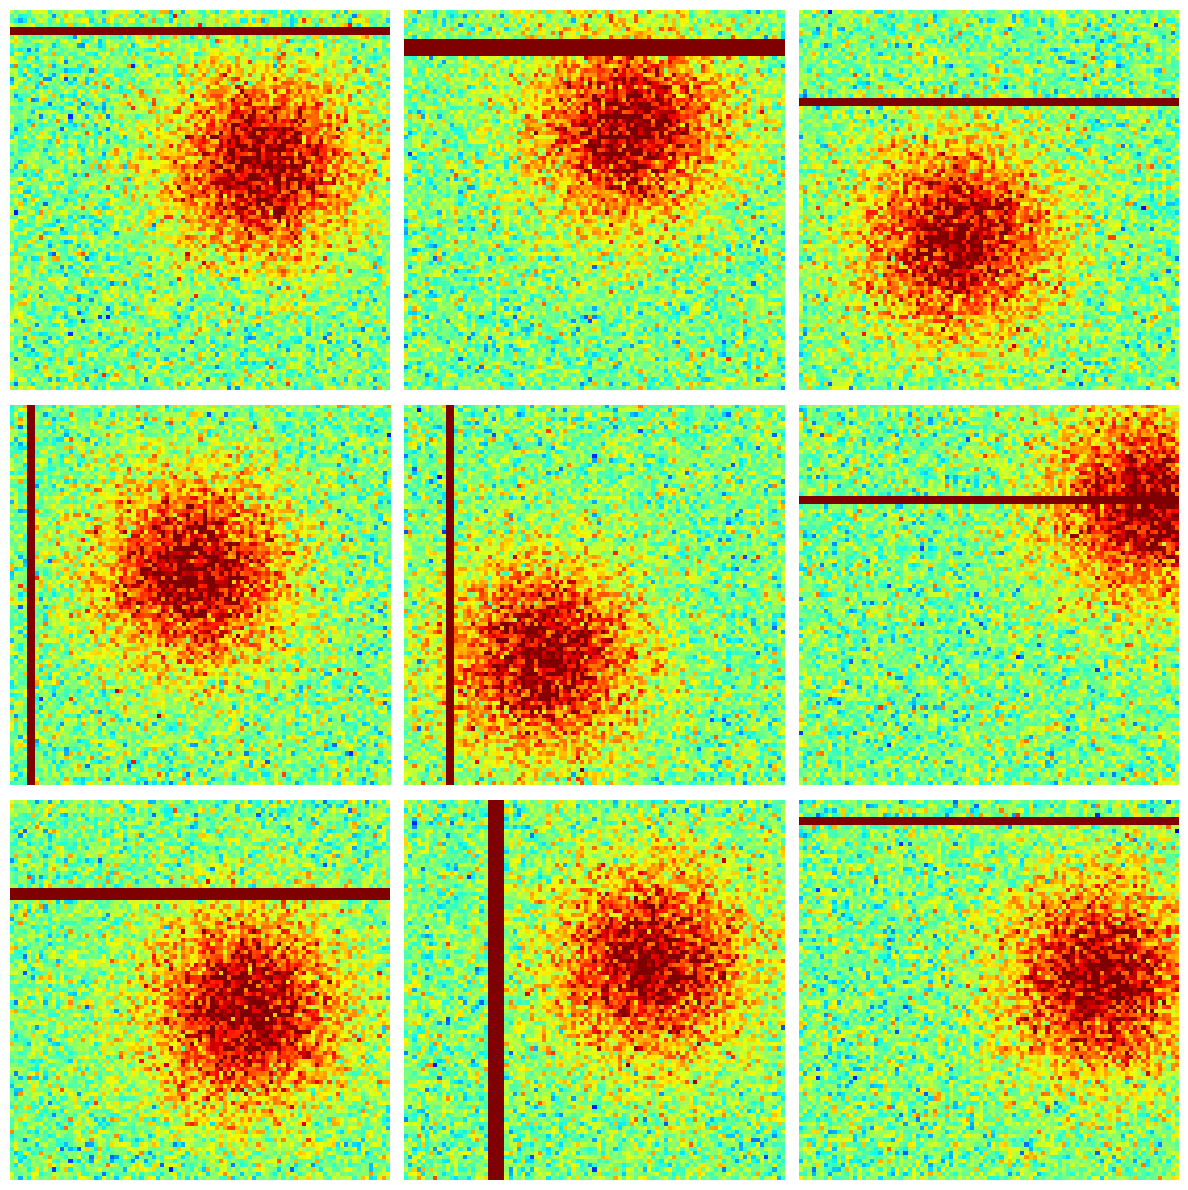

In [ ]:
# Sample images with their occlusion bars.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# TensorDataset with one tensor - autoencoders have no labels, the input is the
# target. Hence x[0] in the loop below.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_tensor = torch.tensor(images, dtype=torch.float , device=device)

train_dataset = TensorDataset(train_tensor)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)


In [ ]:
# Encoder: (1,91,91) -> (4,22,22), reducing 8281 values to 1936.
# Decoder: ConvTranspose2d back up to (1,91,91).
# Tanh on the output bounds it to [-1,1], matching the data's range - always
# match the output activation to the target's range (Sigmoid for [0,1], none for
# unbounded).
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ENCODER
        self.enc = nn.Sequential(
            # Input: (1, 91, 91) -> Output after Conv2d+ReLU: (6, 91, 91)
            nn.Conv2d(1, 6, 3,padding = 1),
            nn.ReLU(),
            # Output after MaxPool2d: (6, 45, 45)
            nn.MaxPool2d((2,2)),

            # Input: (6, 45, 45) -> Output after Conv2d+ReLU: (4, 45, 45)
            nn.Conv2d(6,4,3,padding = 1),
            nn.ReLU(),
            # Output after MaxPool2d: (4, 22, 22)
            nn.MaxPool2d((2,2))
        )

        # DECODER
        self.dec = nn.Sequential(
            # Input: (4, 22, 22) -> Output after ConvTranspose2d+ReLU: (6, 45, 45)
            nn.ConvTranspose2d(4,6,3,2),
            nn.ReLU(),

            # Input: (6, 45, 45) -> Output after ConvTranspose2d: (1, 91, 91)
            nn.ConvTranspose2d(6,1,3,2),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

In [ ]:
test_model = AutoEncoder()
test_model.to(device)

AutoEncoder(
  (enc): Sequential(
    (0): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (dec): Sequential(
    (0): ConvTranspose2d(4, 6, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(6, 1, kernel_size=(3, 3), stride=(2, 2))
    (3): Tanh()
  )
)

In [ ]:
# torchsummary - check the decoder really lands on 91x91. Transposed convolution
# sizes are easy to get wrong by a pixel or two.
torchsummary.summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
              ReLU-2            [-1, 6, 91, 91]               0
         MaxPool2d-3            [-1, 6, 45, 45]               0
            Conv2d-4            [-1, 4, 45, 45]             220
              ReLU-5            [-1, 4, 45, 45]               0
         MaxPool2d-6            [-1, 4, 22, 22]               0
   ConvTranspose2d-7            [-1, 6, 45, 45]             222
              ReLU-8            [-1, 6, 45, 45]               0
   ConvTranspose2d-9            [-1, 1, 91, 91]              55
             Tanh-10            [-1, 1, 91, 91]               0
Total params: 557
Trainable params: 557
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 1.30
Params size (MB): 0.00
Estimated Total Siz

In [ ]:
# Training. lossFunc(yhat, x_batch) - target is the input. That single line is
# what makes this an autoencoder and what makes it self-supervised.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-4
  epochs = 50

  lossFunc = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x in train_loader:
      x_batch = x[0]
      yhat = model(x_batch)

      loss = lossFunc(yhat, x_batch) # Use the unpacked input to calculate error.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [ ]:
model, losses = train_model()

Epoch : 0 | loss : 0.1723864905834198 
Epoch : 10 | loss : 0.058346111834049225 
Epoch : 20 | loss : 0.05021737974882126 
Epoch : 30 | loss : 0.04569534295797348 
Epoch : 40 | loss : 0.04317773631215095 
Epoch : 49 | loss : 0.041710041850805284 


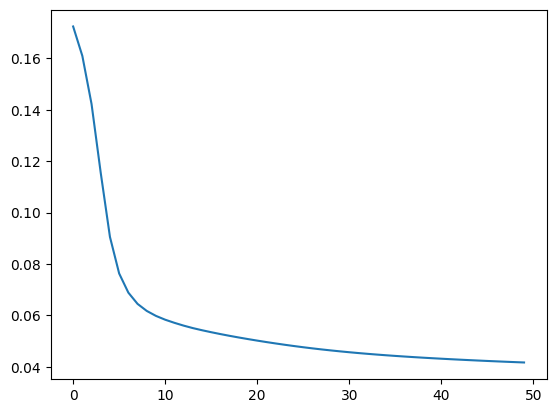

In [ ]:
# Reconstruction loss.
plt.plot(losses);

In [ ]:
subset = train_tensor[2:10]

output = model(subset)

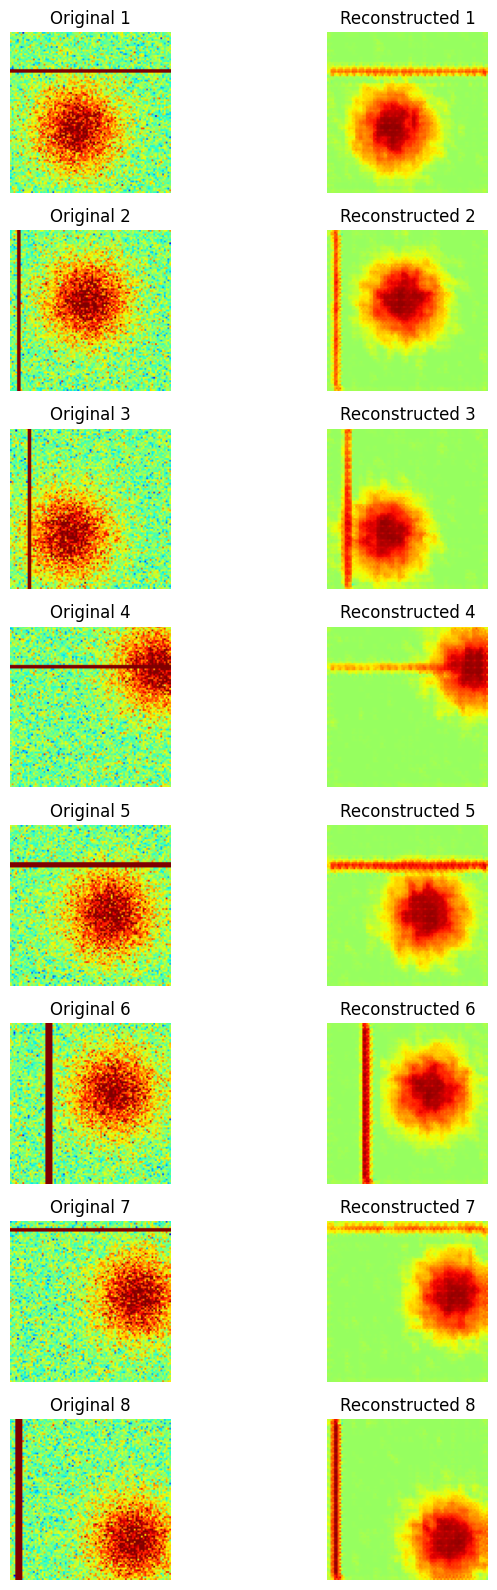

In [ ]:
# Originals (left) vs reconstructions (right).
# The occlusion bars should be largely GONE: the bottleneck kept the Gaussian
# structure, which recurs in every image, and dropped the bars, which do not.
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = subset.detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Now train the model without occulsion then try..

In [ ]:
# Second experiment: the same data generator with the occlusion block removed.
# Clean images only.
img_size = 91
n_perClass = 1000

sigma = np.linspace(2,20,n_perClass)

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n_perClass , 1, img_size,img_size), dtype=float)

for i in range(n_perClass):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i]))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G - noise


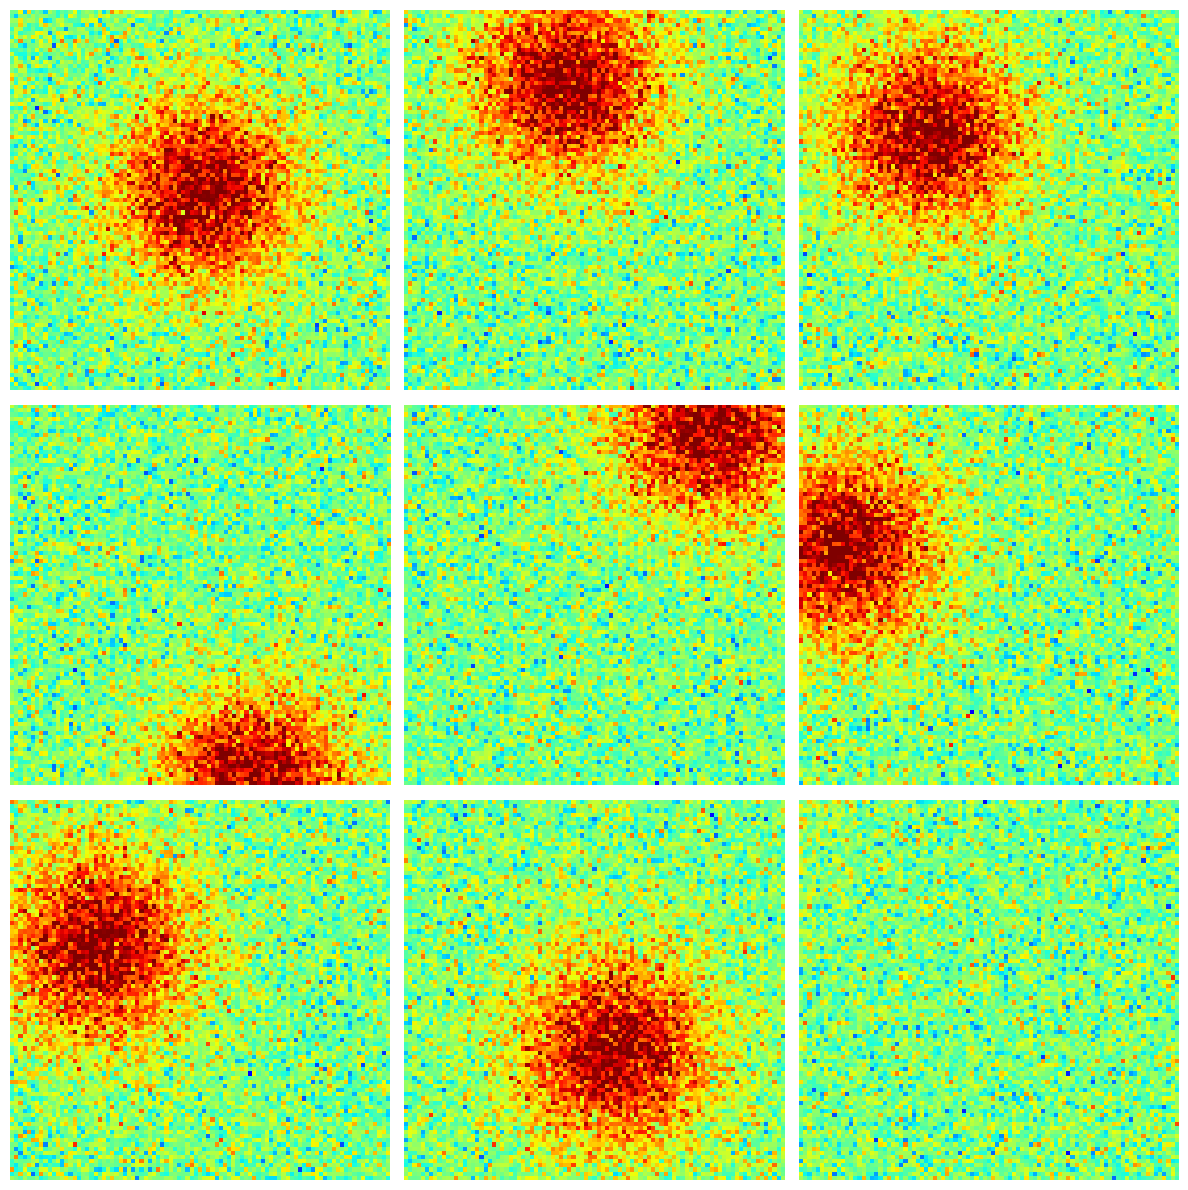

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n_perClass, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# A fresh loader on clean data.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_tensor_non = torch.tensor(images, dtype=torch.float , device=device)

train_dataset = TensorDataset(train_tensor_non)

bs = 16
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)


In [ ]:
# Same architecture, same loss, trained only on clean images.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-3
  epochs = 100

  lossFunc = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x in train_loader:
      x_batch = x[0]
      yhat = model(x_batch)

      loss = lossFunc(yhat, x_batch) # Use the unpacked input to calculate error.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [ ]:
model, losses = train_model()

Epoch : 0 | loss : 0.17234560943418933 
Epoch : 10 | loss : 0.041358363424097336 
Epoch : 20 | loss : 0.039093406690705206 
Epoch : 30 | loss : 0.03848752781989113 
Epoch : 40 | loss : 0.03805682772109585 
Epoch : 50 | loss : 0.03770740834936019 
Epoch : 60 | loss : 0.03752135509444821 
Epoch : 70 | loss : 0.03738486670678662 
Epoch : 80 | loss : 0.037270276596949946 
Epoch : 90 | loss : 0.03717943563336326 
Epoch : 99 | loss : 0.037111469334171664 


In [ ]:
# The test: feed the clean-trained model the OCCLUDED images from earlier.
subset = train_tensor[2:10] # Using the data with occulsion.

output = model(subset)

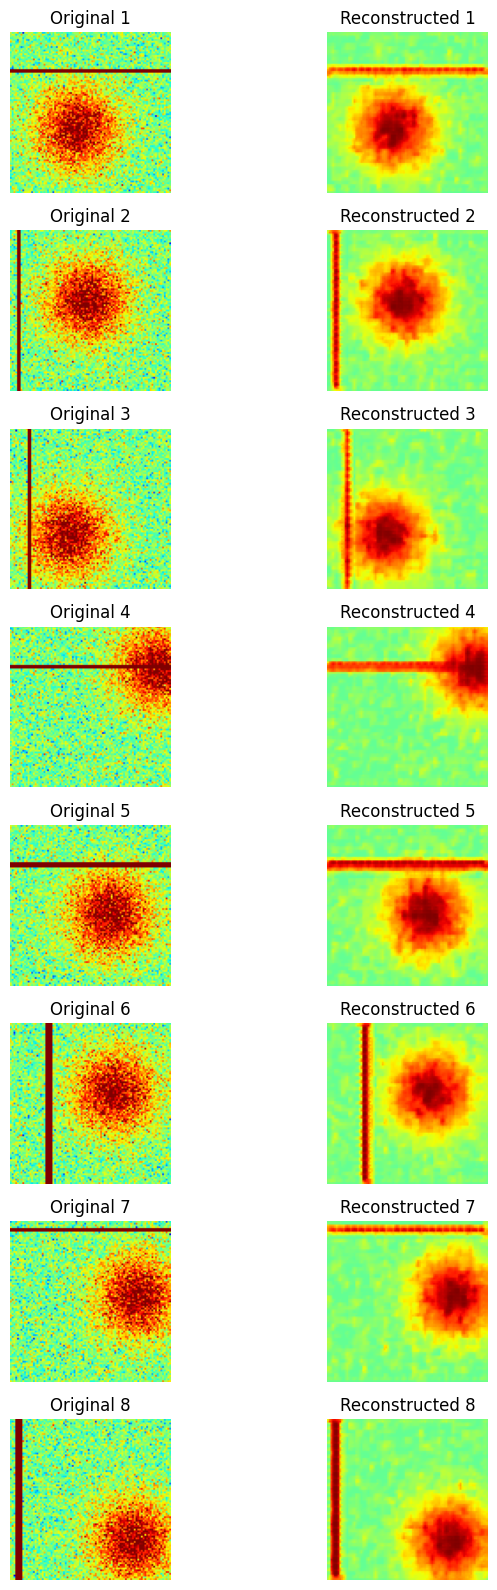

In [ ]:
# The result. The bars survive - this model has no reason to treat them as
# noise, because it has never seen anything like them.
# Compare with the first model's output. Identical architecture, identical loss,
# opposite behaviour, entirely because of what each one was trained on.
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = subset.detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Conclusion

This notebook demonstrates the training of an AutoEncoder to reconstruct images with and without occlusions.

We observed that the model trained on images *with* occlusions was able to denoise and reconstruct the original Gaussian shapes reasonably well, indicating its ability to learn robust representations despite incomplete input.

Conversely, the model trained on images *without* occlusions, when presented with occluded data, struggled to fully remove the occlusions, highlighting the importance of training data characteristics for the desired task.

## Conclusion

This notebook demonstrates the training of an AutoEncoder to reconstruct images with and without occlusions.

We observed that the model trained on images *with* occlusions was able to denoise and reconstruct the original Gaussian shapes reasonably well, indicating its ability to learn robust representations despite incomplete input.

Conversely, the model trained on images *without* occlusions, when presented with occluded data, struggled to fully remove the occlusions, highlighting the importance of training data characteristics for the desired task.